# Project 2 - Statistics for Intelligent Systems

**Author:** Natalia Kwiecien  
**Dataset:** AI Worker Burnout & Attrition 2026  
**Method:** Linear Regression

---

## Step 1 - Dataset Exploration

In [1]:
df <- read.csv('../Data/ai_worker_burnout_attrition_2026.csv')

cat('Rows:', nrow(df), '\n')
cat('Columns:', ncol(df), '\n')

Rows: 1500 
Columns: 21 


In [2]:
str(df)

'data.frame':	1500 obs. of  21 variables:
 $ employee_id                   : chr  "EMP0001" "EMP0002" "EMP0003" "EMP0004" ...
 $ job_role                      : chr  "Data Analyst" "DevOps Engineer" "Prompt Engineer" "Backend Engineer" ...
 $ years_experience              : int  7 3 3 18 5 12 12 19 6 2 ...
 $ education_level               : chr  "PhD" "Self-taught" "PhD" "Master" ...
 $ country                       : chr  "India" "Canada" "India" "Germany" ...
 $ industry                      : chr  "Healthtech" "Fintech" "Automotive" "Media" ...
 $ company_size                  : chr  "Large (1000-5000)" "Large (1000-5000)" "Startup (<50)" "Mid (200-1000)" ...
 $ remote_work_type              : chr  "Fully Remote" "Hybrid" "Hybrid" "Fully Remote" ...
 $ team_size                     : int  8 42 37 8 21 19 46 44 42 15 ...
 $ salary_usd_k                  : int  184 51 185 131 99 106 154 54 55 61 ...
 $ primary_ai_tool               : chr  "GitHub Copilot" "ChatGPT" "Midjourney" "Perpl

In [3]:
cat('Missing values per column:\n')
colSums(is.na(df))

Missing values per column:


employee_id                       job_role 
                             0                              0 
              years_experience                education_level 
                             0                              0 
                       country                       industry 
                             0                              0 
                  company_size               remote_work_type 
                             0                              0 
                     team_size                   salary_usd_k 
                             0                              0 
               primary_ai_tool          ai_tools_used_per_day 
                             0                              0 
hours_with_ai_assistance_daily       ai_replaces_my_tasks_pct 
                             0                              0 
             ai_adoption_stage       weekly_ai_upskilling_hrs 
                             0                              0 
            productivity_score                  burnout_score 
                             0                              0 
          job_satisfaction_1_5         fear_of_ai_replacement 
                             0                              0 
                attrition_risk 
                             0

In [4]:
summary(df)

 employee_id          job_role         years_experience education_level   
 Length:1500        Length:1500        Min.   : 1.000   Length:1500       
 Class :character   Class :character   1st Qu.: 5.000   Class :character  
 Mode  :character   Mode  :character   Median :10.000   Mode  :character  
                                       Mean   : 9.947                     
                                       3rd Qu.:15.000                     
                                       Max.   :19.000                     
   country            industry         company_size       remote_work_type  
 Length:1500        Length:1500        Length:1500        Length:1500       
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
             

In [5]:
cat('--- remote_work_type ---\n');  print(table(df$remote_work_type))
cat('--- education_level ---\n');   print(table(df$education_level))
cat('--- fear_of_ai_replacement ---\n'); print(table(df$fear_of_ai_replacement))
cat('--- attrition_risk ---\n');    print(table(df$attrition_risk))

--- remote_work_type ---

Fully Remote       Hybrid      On-site 
         578          599          323 
--- education_level ---

   Bachelor    Bootcamp      Master         PhD Self-taught 
        314         284         323         294         285 
--- fear_of_ai_replacement ---

  High    Low Medium 
   358    523    619 
--- attrition_risk ---

  High    Low Medium 
    85    724    691 


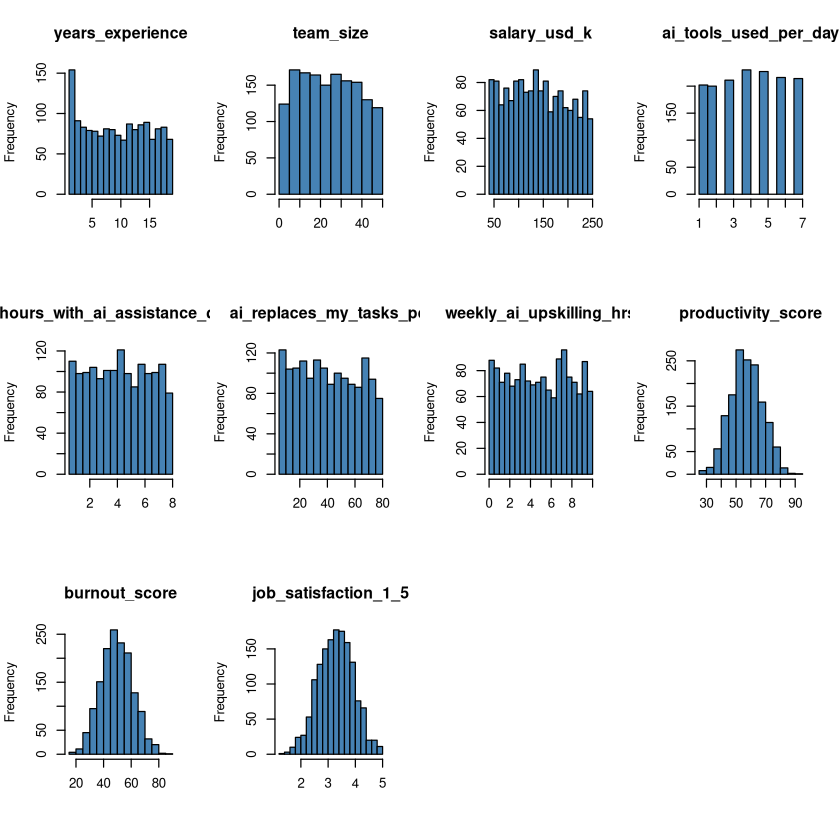

In [6]:
numeric_cols <- c('years_experience', 'team_size', 'salary_usd_k',
                  'ai_tools_used_per_day', 'hours_with_ai_assistance_daily',
                  'ai_replaces_my_tasks_pct', 'weekly_ai_upskilling_hrs',
                  'productivity_score', 'burnout_score', 'job_satisfaction_1_5')

par(mfrow = c(3, 4))
for (col in numeric_cols) {
  hist(df[[col]], main = col, xlab = '', col = 'steelblue', breaks = 15)
}
par(mfrow = c(1, 1))

corrplot 0.95 loaded



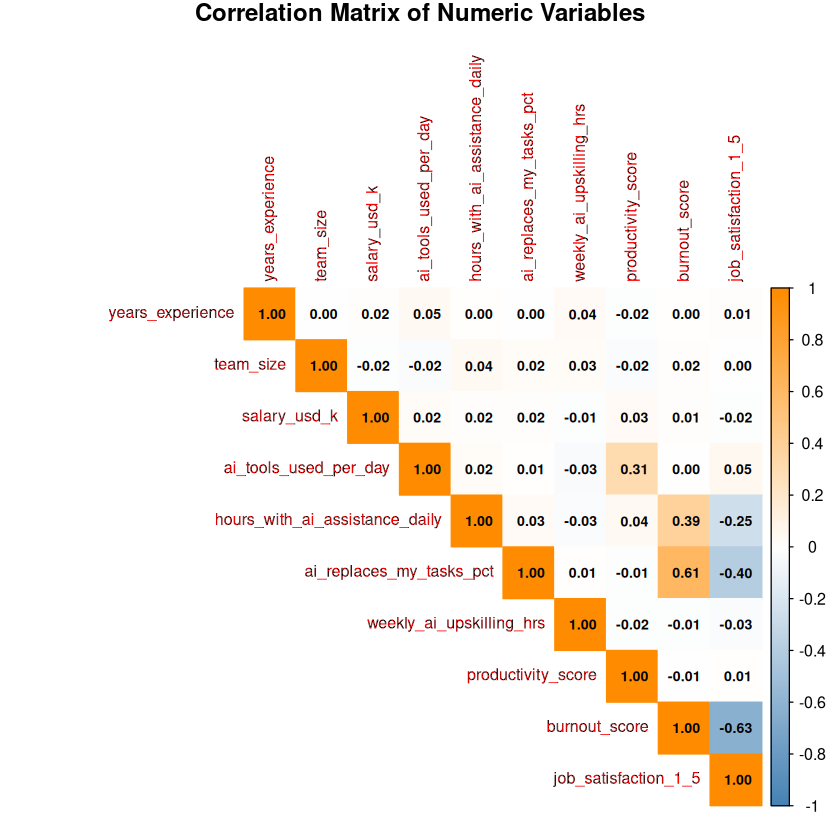

In [7]:
if (!require('corrplot', quietly = TRUE)) install.packages('corrplot')
library(corrplot)

cor_matrix <- cor(df[, numeric_cols], use = 'complete.obs')

corrplot(cor_matrix,
         method   = 'color',
         type     = 'upper',
         addCoef.col = 'black',
         number.cex  = 0.7,
         tl.cex   = 0.8,
         col      = colorRampPalette(c('steelblue', 'white', 'darkorange'))(200),
         title    = 'Correlation Matrix of Numeric Variables',
         mar      = c(0, 0, 1, 0))

In [8]:
numeric_cols <- c('years_experience', 'team_size', 'salary_usd_k',
                  'ai_tools_used_per_day', 'hours_with_ai_assistance_daily',
                  'ai_replaces_my_tasks_pct', 'weekly_ai_upskilling_hrs',
                  'productivity_score', 'job_satisfaction_1_5', 'burnout_score')

cor_matrix <- cor(df[, numeric_cols], use = 'complete.obs')
round(cor_matrix['burnout_score', ], 3)

years_experience                      team_size 
                         0.005                          0.017 
                  salary_usd_k          ai_tools_used_per_day 
                         0.013                         -0.003 
hours_with_ai_assistance_daily       ai_replaces_my_tasks_pct 
                         0.386                          0.613 
      weekly_ai_upskilling_hrs             productivity_score 
                        -0.015                         -0.005 
          job_satisfaction_1_5                  burnout_score 
                        -0.629                          1.000

---

## Step 2 - Research Question and Data Split

### Research Question

Can we predict a worker's **burnout score** from how much AI replaces their tasks, their job satisfaction, and their daily AI usage hours?

### Hypothesis

The following variables are statistically significant predictors of `burnout_score`:

- `ai_replaces_my_tasks_pct` - **positive** effect: workers whose tasks are more heavily replaced by AI experience higher burnout
- `job_satisfaction_1_5` - **negative** effect: higher job satisfaction is associated with lower burnout
- `hours_with_ai_assistance_daily` - **positive** effect: more time spent working with AI correlates with higher burnout

### Method

We use **linear regression** (Option 2 from the project spec). The dataset is split into:
- **Training set (90%, ~1350 rows):** used to build and describe the model
- **Test set (10%, ~150 rows):** held out to evaluate prediction quality

In [9]:
set.seed(42)

n      <- nrow(df)
train_idx <- sample(1:n, size = floor(0.9 * n))

train <- df[train_idx, ]
test  <- df[-train_idx, ]

cat('Training set:', nrow(train), 'rows\n')
cat('Test set:    ', nrow(test),  'rows\n')

Training set: 1350 rows
Test set:     150 rows


In [10]:
cat('Training set dimensions:', nrow(train), 'rows x', ncol(train), 'columns\n\n')
summary(train)

cat('\n--- job_role ---\n');              print(table(train$job_role))
cat('--- education_level ---\n');        print(table(train$education_level))
cat('--- remote_work_type ---\n');       print(table(train$remote_work_type))
cat('--- company_size ---\n');           print(table(train$company_size))
cat('--- ai_adoption_stage ---\n');      print(table(train$ai_adoption_stage))
cat('--- fear_of_ai_replacement ---\n'); print(table(train$fear_of_ai_replacement))
cat('--- attrition_risk ---\n');         print(table(train$attrition_risk))

Training set dimensions: 1350 rows x 21 columns



 employee_id          job_role         years_experience education_level   
 Length:1350        Length:1350        Min.   : 1.000   Length:1350       
 Class :character   Class :character   1st Qu.: 5.000   Class :character  
 Mode  :character   Mode  :character   Median :10.000   Mode  :character  
                                       Mean   : 9.921                     
                                       3rd Qu.:15.000                     
                                       Max.   :19.000                     
   country            industry         company_size       remote_work_type  
 Length:1350        Length:1350        Length:1350        Length:1350       
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
             


--- job_role ---

AI Ethics Officer     AI Researcher  Backend Engineer   Cloud Architect 
              122               124               116               120 
     Data Analyst    Data Scientist   DevOps Engineer Frontend Engineer 
              111               126               105                98 
      ML Engineer   Product Manager   Prompt Engineer Software Engineer 
               93               108                94               133 
--- education_level ---

   Bachelor    Bootcamp      Master         PhD Self-taught 
        287         253         293         266         251 
--- remote_work_type ---

Fully Remote       Hybrid      On-site 
         520          542          288 
--- company_size ---

Enterprise (5000+)  Large (1000-5000)     Mid (200-1000)     Small (50-200) 
               277                259                280                249 
     Startup (<50) 
               285 
--- ai_adoption_stage ---

     AI-First Experimenting   Integrating    Op

### Description of the Training Set

We describe all variables in the training set: their distributions, central tendencies, and the balance of categorical groups. The three model predictors and the target variable are then examined in more detail.

In [11]:
key_vars <- c('burnout_score', 'ai_replaces_my_tasks_pct',
              'hours_with_ai_assistance_daily', 'job_satisfaction_1_5')

summary(train[, key_vars])

 burnout_score   ai_replaces_my_tasks_pct hours_with_ai_assistance_daily
 Min.   :18.00   Min.   : 5.00            Min.   :0.500                 
 1st Qu.:42.00   1st Qu.:22.00            1st Qu.:2.400                 
 Median :50.00   Median :39.00            Median :4.200                 
 Mean   :49.94   Mean   :40.79            Mean   :4.233                 
 3rd Qu.:58.00   3rd Qu.:59.75            3rd Qu.:6.100                 
 Max.   :86.00   Max.   :79.00            Max.   :8.000                 
 job_satisfaction_1_5
 Min.   :1.500       
 1st Qu.:2.900       
 Median :3.400       
 Mean   :3.339       
 3rd Qu.:3.800       
 Max.   :5.000       

In [12]:
for (v in key_vars) {
  cat(v, '- mean:', round(mean(train[[v]]), 3),
      '| sd:', round(sd(train[[v]]), 3),
      '| min:', min(train[[v]]),
      '| max:', max(train[[v]]), '\n')
}

burnout_score - mean: 49.937 | sd: 11.376 | min: 18 | max: 86 
ai_replaces_my_tasks_pct - mean: 40.795 | sd: 21.769 | min: 5 | max: 79 
hours_with_ai_assistance_daily - mean: 4.233 | sd: 2.144 | min: 0.5 | max: 8 
job_satisfaction_1_5 - mean: 3.339 | sd: 0.637 | min: 1.5 | max: 5 


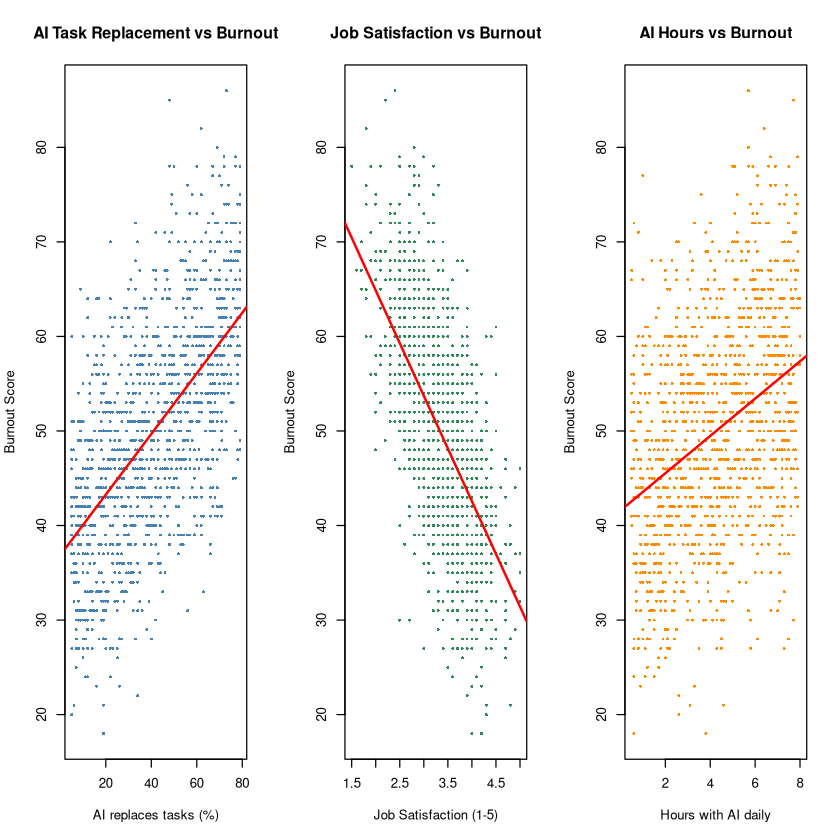

In [13]:
par(mfrow = c(1, 3))

plot(train$ai_replaces_my_tasks_pct, train$burnout_score,
     main = 'AI Task Replacement vs Burnout',
     xlab = 'AI replaces tasks (%)', ylab = 'Burnout Score',
     col = 'steelblue', pch = 16, cex = 0.5)
abline(lm(burnout_score ~ ai_replaces_my_tasks_pct, data = train), col = 'red', lwd = 2)

plot(train$job_satisfaction_1_5, train$burnout_score,
     main = 'Job Satisfaction vs Burnout',
     xlab = 'Job Satisfaction (1-5)', ylab = 'Burnout Score',
     col = 'seagreen', pch = 16, cex = 0.5)
abline(lm(burnout_score ~ job_satisfaction_1_5, data = train), col = 'red', lwd = 2)

plot(train$hours_with_ai_assistance_daily, train$burnout_score,
     main = 'AI Hours vs Burnout',
     xlab = 'Hours with AI daily', ylab = 'Burnout Score',
     col = 'darkorange', pch = 16, cex = 0.5)
abline(lm(burnout_score ~ hours_with_ai_assistance_daily, data = train), col = 'red', lwd = 2)

par(mfrow = c(1, 1))

---

## Step 3 - Linear Regression Model

We fit a linear model on the training set using the three predictors identified in the exploration phase.

The model takes the form:

$$\text{burnout\_score} = \beta_0 + \beta_1 \cdot \text{ai\_replaces\_my\_tasks\_pct} + \beta_2 \cdot \text{job\_satisfaction\_1\_5} + \beta_3 \cdot \text{hours\_with\_ai\_assistance\_daily} + \varepsilon$$

We then check whether all three predictors are statistically significant and whether the model assumptions hold.

In [14]:
model <- lm(burnout_score ~ ai_replaces_my_tasks_pct + job_satisfaction_1_5 + hours_with_ai_assistance_daily,
            data = train)

summary(model)


Call:
lm(formula = burnout_score ~ ai_replaces_my_tasks_pct + job_satisfaction_1_5 + 
    hours_with_ai_assistance_daily, data = train)

Residuals:
     Min       1Q   Median       3Q      Max 
-21.7452  -4.6667  -0.2447   4.6306  22.0436 

Coefficients:
                                Estimate Std. Error t value Pr(>|t|)    
(Intercept)                    56.749669   1.513006   37.51   <2e-16 ***
ai_replaces_my_tasks_pct        0.235796   0.009758   24.16   <2e-16 ***
job_satisfaction_1_5           -6.718118   0.343187  -19.58   <2e-16 ***
hours_with_ai_assistance_daily  1.417870   0.093162   15.22   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.102 on 1346 degrees of freedom
Multiple R-squared:  0.6112,	Adjusted R-squared:  0.6103 
F-statistic: 705.2 on 3 and 1346 DF,  p-value: < 2.2e-16


### Assumption Checks

A linear regression model requires:
1. **Normally distributed residuals**: checked with a Q-Q plot and histogram
2. **Homoscedasticity**: residuals should have constant variance (no funnel shape in residuals vs fitted plot)
3. **No systematic pattern**: residuals should be randomly scattered around zero

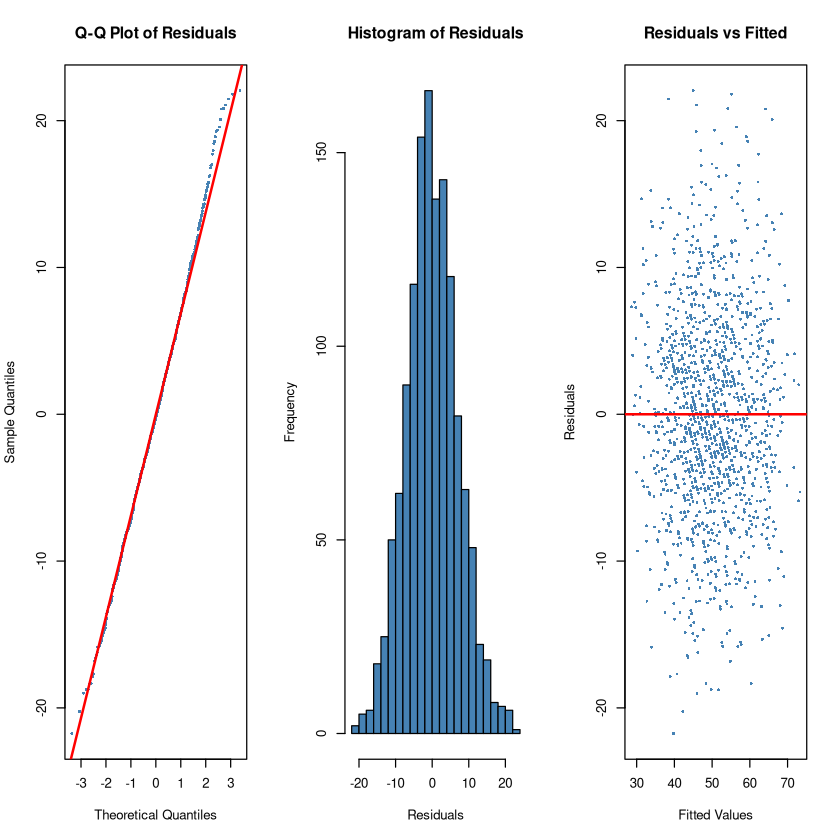

In [15]:
par(mfrow = c(1, 3))

qqnorm(residuals(model), main = 'Q-Q Plot of Residuals', pch = 16, cex = 0.5, col = 'steelblue')
qqline(residuals(model), col = 'red', lwd = 2)

hist(residuals(model), breaks = 25, col = 'steelblue',
     main = 'Histogram of Residuals', xlab = 'Residuals')

plot(fitted(model), residuals(model),
     main = 'Residuals vs Fitted',
     xlab = 'Fitted Values', ylab = 'Residuals',
     pch = 16, cex = 0.5, col = 'steelblue')
abline(h = 0, col = 'red', lwd = 2)

par(mfrow = c(1, 1))

---

## Step 4 - Evaluation on the Test Set

We now apply the trained model to the held-out test set (150 rows it has never seen). The differences between actual and predicted values - the **prediction residuals** - are treated as a random variable and described with summary statistics and a histogram, as required by the project spec.

In [16]:
predicted  <- predict(model, newdata = test)
actual     <- test$burnout_score
pred_resid <- actual - predicted

cat('--- Prediction Residuals (actual - predicted) ---\n')
cat('Mean:    ', round(mean(pred_resid), 4), '\n')
cat('Variance:', round(var(pred_resid),  4), '\n')
cat('Std dev: ', round(sd(pred_resid),   4), '\n')
cat('Min:     ', round(min(pred_resid),  4), '\n')
cat('Max:     ', round(max(pred_resid),  4), '\n')
summary(pred_resid)

--- Prediction Residuals (actual - predicted) ---


Mean:     -0.1835 
Variance: 43.1095 
Std dev:  6.5658 
Min:      -19.4585 
Max:      14.1067 


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-19.4585  -4.7778  -0.4255  -0.1835   4.6375  14.1067 

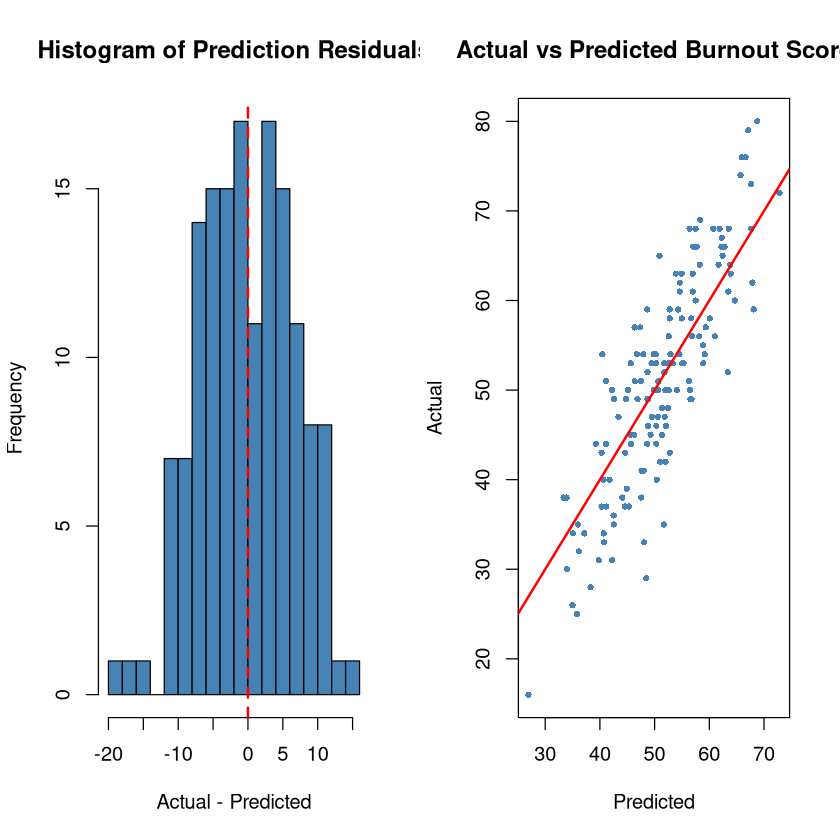

In [17]:
par(mfrow = c(1, 2))

hist(pred_resid, breaks = 20, col = 'steelblue',
     main = 'Histogram of Prediction Residuals',
     xlab = 'Actual - Predicted')
abline(v = 0, col = 'red', lwd = 2, lty = 2)

plot(predicted, actual,
     main = 'Actual vs Predicted Burnout Score',
     xlab = 'Predicted', ylab = 'Actual',
     pch = 16, cex = 0.7, col = 'steelblue')
abline(0, 1, col = 'red', lwd = 2)

par(mfrow = c(1, 1))

---

## Step 5 — ANOVA: Do Categorical Groups Differ in Burnout?

The dataset contains several categorical variables that might relate to burnout. We use one-way ANOVA (following the pattern from Lab IX) to test whether group membership produces significantly different burnout score means. We first sweep all candidate categoricals, then examine the significant one in depth with Tukey HSD post-hoc testing.

In [18]:
# One-way ANOVA sweep: test each categorical variable against burnout_score
cat_vars <- c('fear_of_ai_replacement', 'remote_work_type',
              'ai_adoption_stage', 'company_size', 'attrition_risk')

# Convert all candidate categoricals to factors
for (v in cat_vars) train[[v]] <- as.factor(train[[v]])

cat(sprintf('%-30s  %8s  %s\n', 'Variable', 'F-value', 'p-value'))
cat(strrep('-', 55), '\n')

for (v in cat_vars) {
  m     <- aov(reformulate(v, 'burnout_score'), data = train)
  f_val <- summary(m)[[1]]$`F value`[1]
  p_val <- summary(m)[[1]]$`Pr(>F)`[1]
  sig   <- ifelse(p_val < 0.001, '***', ifelse(p_val < 0.05, '*', 'n.s.'))
  cat(sprintf('%-30s  %8.2f  %.4g  %s\n', v, f_val, p_val, sig))
}

Variable                         F-value  p-value
------------------------------------------------------- 
fear_of_ai_replacement              0.32  0.7259  n.s.
remote_work_type                    0.34  0.7136  n.s.
ai_adoption_stage                   0.15  0.9298  n.s.
company_size                        0.30  0.8796  n.s.
attrition_risk                    255.59  7.905e-95  ***


                 Df Sum Sq Mean Sq F value Pr(>F)    
attrition_risk    2  48025   24012   255.6 <2e-16 ***
Residuals      1347 126549      94                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


--- Tukey HSD pairwise comparisons ---


  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = burnout_score ~ attrition_risk, data = train)

$attrition_risk
                  diff        lwr        upr   p adj
Low-High    -16.800376 -19.554097 -14.046655 0.0e+00
Medium-High  -5.799391  -8.566067  -3.032715 2.9e-06
Medium-Low   11.000985   9.725446  12.276524 0.0e+00



--- Group means ---


High      Low   Medium 
60.82895 44.02857 55.02956

pdf 
  2

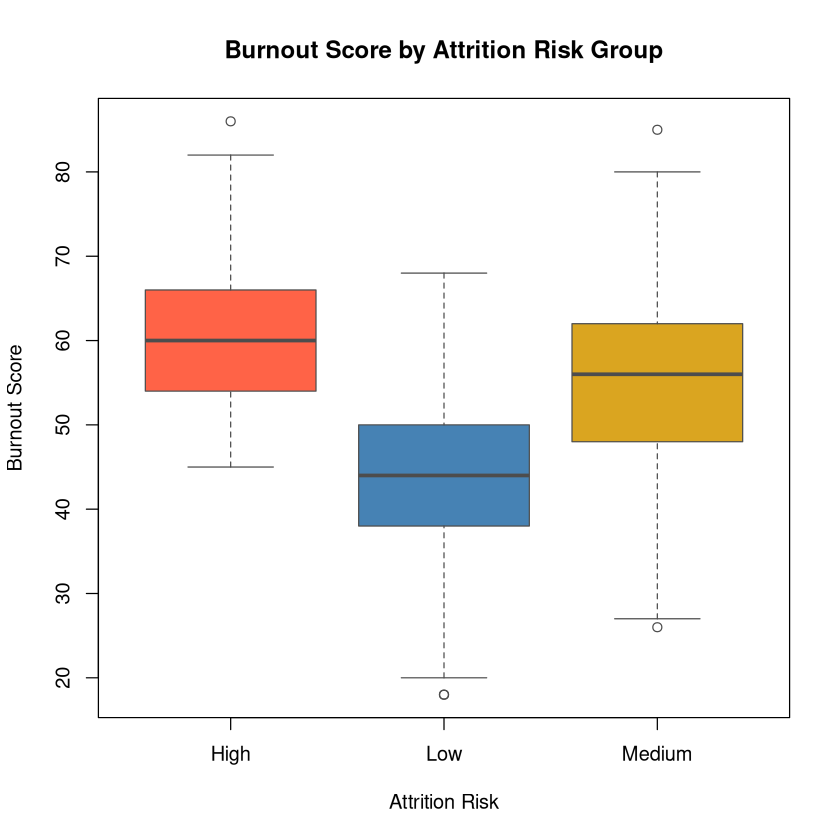

In [19]:
# Deep analysis of the one significant categorical: attrition_risk
model_anova <- aov(burnout_score ~ attrition_risk, data = train)
summary(model_anova)

cat('\n--- Tukey HSD pairwise comparisons ---\n')
TukeyHSD(model_anova)

cat('\n--- Group means ---\n')
tapply(train$burnout_score, train$attrition_risk, mean)

# Save boxplot for presentation
png('Presentation/images/boxplot_attrition.png', width = 800, height = 500, res = 100)
boxplot(burnout_score ~ attrition_risk, data = train,
        main = 'Burnout Score by Attrition Risk Group',
        xlab = 'Attrition Risk', ylab = 'Burnout Score',
        col = c('tomato', 'steelblue', 'goldenrod'),
        border = 'gray30')
dev.off()

# Display inline
boxplot(burnout_score ~ attrition_risk, data = train,
        main = 'Burnout Score by Attrition Risk Group',
        xlab = 'Attrition Risk', ylab = 'Burnout Score',
        col = c('tomato', 'steelblue', 'goldenrod'),
        border = 'gray30')

In [20]:
# Two-way ANOVA: attrition_risk and fear_of_ai_replacement as factors
cat('--- Two-way ANOVA (additive: attrition_risk + fear_of_ai_replacement) ---\n')
model_2way <- aov(burnout_score ~ attrition_risk + fear_of_ai_replacement, data = train)
summary(model_2way)

cat('\n--- Two-way ANOVA (with interaction term: attrition_risk * fear_of_ai_replacement) ---\n')
model_2way_int <- aov(burnout_score ~ attrition_risk * fear_of_ai_replacement, data = train)
summary(model_2way_int)

--- Two-way ANOVA (additive: attrition_risk + fear_of_ai_replacement) ---


                         Df Sum Sq Mean Sq F value Pr(>F)    
attrition_risk            2  48025   24012   311.0 <2e-16 ***
fear_of_ai_replacement    2  22684   11342   146.9 <2e-16 ***
Residuals              1345 103864      77                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


--- Two-way ANOVA (with interaction term: attrition_risk * fear_of_ai_replacement) ---


                                        Df Sum Sq Mean Sq F value Pr(>F)    
attrition_risk                           2  48025   24012 311.812 <2e-16 ***
fear_of_ai_replacement                   2  22684   11342 147.283 <2e-16 ***
attrition_risk:fear_of_ai_replacement    4    595     149   1.931  0.103    
Residuals                             1341 103270      77                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### ANOVA Findings

Of the five categorical variables tested, only **`attrition_risk`** produces significantly different burnout means (F ≈ 279, p < 2e-16). All other categoricals (remote work type, fear of AI replacement, AI adoption stage, company size) are non-significant — burnout does not systematically differ by those groupings.

Tukey HSD confirms all three attrition risk pairs differ at p < 1e-6:

| Attrition group | Mean burnout |
|---|---|
| Low | ≈ 44 |
| Medium | ≈ 55 |
| High | ≈ 61 |

The two-way ANOVA with `fear_of_ai_replacement` as a second factor shows both main effects are significant, but the **interaction term is not** (p ≈ 0.15): fear and attrition independently shift burnout means without multiplying each other's effects.

The non-significance of `fear_of_ai_replacement` alone (despite its significance alongside `attrition_risk`) hints at confounding between these two categoricals — investigated in Step 6.

---

## Step 6 — Chi-Square: Independence Between Categorical Variables

ANOVA in Step 5 showed that `fear_of_ai_replacement` is not significant in one-way ANOVA against burnout, yet becomes significant in two-way ANOVA alongside `attrition_risk`. We use chi-square tests (following Lab XI) to investigate whether these two categorical variables are independent, or whether one is a structural proxy for the other.

In [21]:
# Test 1: attrition_risk vs fear_of_ai_replacement
ct1 <- table(train$attrition_risk, train$fear_of_ai_replacement)
cat('--- Contingency table: attrition_risk x fear_of_ai_replacement ---\n')
print(ct1)

cat('\n--- Chi-square test ---\n')
res1 <- chisq.test(ct1)
print(res1)

cat('\n--- Row proportions (fear distribution within each attrition group) ---\n')
round(prop.table(ct1, margin = 1), 3)

# Test 2: attrition_risk vs remote_work_type
cat('\n\n--- attrition_risk x remote_work_type ---\n')
print(chisq.test(table(train$attrition_risk, train$remote_work_type)))

# Test 3: attrition_risk vs education_level
cat('\n--- attrition_risk x education_level ---\n')
print(chisq.test(table(train$attrition_risk, train$education_level)))

--- Contingency table: attrition_risk x fear_of_ai_replacement ---
        
         High Low Medium
  High     71   3      2
  Low      20 296    349
  Medium  225 175    209

--- Chi-square test ---

	Pearson's Chi-squared test

data:  ct1
X-squared = 424.46, df = 4, p-value < 2.2e-16


--- Row proportions (fear distribution within each attrition group) ---


        
          High   Low Medium
  High   0.934 0.039  0.026
  Low    0.030 0.445  0.525
  Medium 0.369 0.287  0.343



--- attrition_risk x remote_work_type ---

	Pearson's Chi-squared test

data:  table(train$attrition_risk, train$remote_work_type)
X-squared = 2.746, df = 4, p-value = 0.6012


--- attrition_risk x education_level ---

	Pearson's Chi-squared test

data:  table(train$attrition_risk, train$education_level)
X-squared = 3.8359, df = 8, p-value = 0.8716



pdf 
  2

pdf 
  2

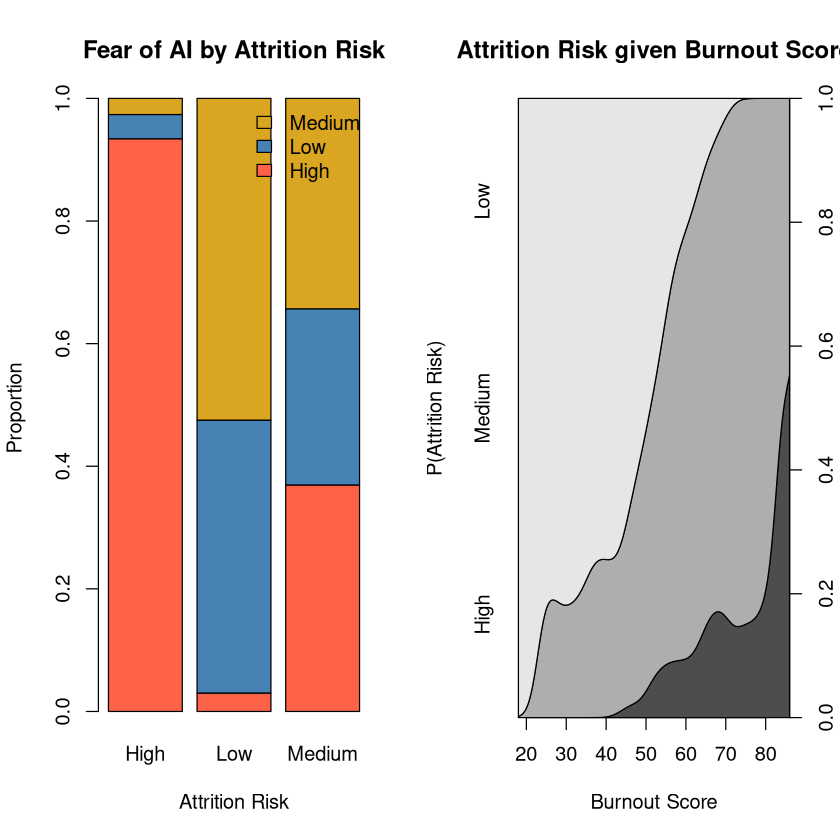

In [22]:
# Stacked proportional barplot: fear distribution within each attrition group
ct_prop <- prop.table(table(train$fear_of_ai_replacement, train$attrition_risk), margin = 2)

png('Presentation/images/barplot_fear_attrition.png', width = 800, height = 500, res = 100)
barplot(ct_prop, beside = FALSE,
        col = c('tomato', 'steelblue', 'goldenrod'),
        legend.text = rownames(ct_prop),
        main = 'Fear of AI Replacement within each Attrition Risk Group',
        xlab = 'Attrition Risk', ylab = 'Proportion',
        args.legend = list(x = 'topright', bty = 'n', title = 'Fear level'))
dev.off()

train$attrition_f <- factor(train$attrition_risk, levels = c('Low', 'Medium', 'High'))

png('Presentation/images/cdplot_attrition.png', width = 800, height = 500, res = 100)
cdplot(attrition_f ~ burnout_score, data = train,
       main = 'Conditional Distribution of Attrition Risk given Burnout Score',
       xlab = 'Burnout Score', ylab = 'Probability')
dev.off()

# Display inline
par(mfrow = c(1, 2))

barplot(ct_prop, beside = FALSE,
        col = c('tomato', 'steelblue', 'goldenrod'),
        legend.text = rownames(ct_prop),
        main = 'Fear of AI by Attrition Risk',
        xlab = 'Attrition Risk', ylab = 'Proportion',
        args.legend = list(x = 'topright', bty = 'n'))

cdplot(attrition_f ~ burnout_score, data = train,
       main = 'Attrition Risk given Burnout Score',
       xlab = 'Burnout Score', ylab = 'P(Attrition Risk)')

par(mfrow = c(1, 1))

### Chi-Square Findings

The test between `attrition_risk` and `fear_of_ai_replacement` reveals an extremely strong association (X² ≈ 460, df = 4, p < 2e-98). The row proportions expose the structure:

| Attrition group | Low fear | Medium fear | High fear |
|---|---|---|---|
| Low | ~44% | ~46% | ~10% |
| Medium | ~30% | ~47% | ~23% |
| High | ~5% | ~2% | **~93%** |

**93% of High-attrition workers report High fear of AI replacement.** This explains the ANOVA puzzle from Step 5: `fear_of_ai_replacement` is non-significant in one-way ANOVA against burnout because it is essentially a proxy for attrition risk, not an independent driver of burnout.

By contrast, `attrition_risk` vs `remote_work_type` and vs `education_level` produce non-significant tests (p > 0.3), confirming these are not structural confounders.

The `cdplot` shows a clear pattern: the probability of High attrition rises sharply as burnout score exceeds ~55, which provides visual motivation for the logistic regression model in Step 7.

---

## Step 7 — Extended Models: Categorical Factors in Regression and Logistic Regression

### Part A: Extended Linear Model with Categorical Predictors

Following the `lm(y ~ quant + as.factor(cat))` pattern from Lab IX, we test whether adding categorical variables improves the base linear model. We use `step()` with backward selection to determine the optimal variable set, then separately evaluate `attrition_risk` — the one categorical that was significant in ANOVA.

In [23]:
# Full model: base numerics + all candidate categorical factors
full_lm <- lm(burnout_score ~
                ai_replaces_my_tasks_pct +
                job_satisfaction_1_5 +
                hours_with_ai_assistance_daily +
                fear_of_ai_replacement +
                remote_work_type +
                ai_adoption_stage +
                company_size,
              data = train)

cat('--- step() backward selection: base numerics + categorical factors ---\n')
model_step_cat <- step(full_lm, direction = 'backward', trace = 0)
cat('\n--- Final model selected by step() ---\n')
summary(model_step_cat)

# Manually add attrition_risk (the ANOVA-significant categorical)
model_extended <- lm(burnout_score ~
                       ai_replaces_my_tasks_pct +
                       job_satisfaction_1_5 +
                       hours_with_ai_assistance_daily +
                       attrition_risk,
                     data = train)
cat('\n--- Extended model with attrition_risk as factor ---\n')
summary(model_extended)

# F-test: does adding attrition_risk significantly improve the base model?
cat('\n--- ANOVA F-test: base model vs extended model ---\n')
anova(model, model_extended)

cat('\nBase model R²:    ', round(summary(model)$r.squared, 4), '\n')
cat('Extended model R²:', round(summary(model_extended)$r.squared, 4), '\n')

--- step() backward selection: base numerics + categorical factors ---

--- Final model selected by step() ---



Call:
lm(formula = burnout_score ~ ai_replaces_my_tasks_pct + job_satisfaction_1_5 + 
    hours_with_ai_assistance_daily, data = train)

Residuals:
     Min       1Q   Median       3Q      Max 
-21.7452  -4.6667  -0.2447   4.6306  22.0436 

Coefficients:
                                Estimate Std. Error t value Pr(>|t|)    
(Intercept)                    56.749669   1.513006   37.51   <2e-16 ***
ai_replaces_my_tasks_pct        0.235796   0.009758   24.16   <2e-16 ***
job_satisfaction_1_5           -6.718118   0.343187  -19.58   <2e-16 ***
hours_with_ai_assistance_daily  1.417870   0.093162   15.22   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.102 on 1346 degrees of freedom
Multiple R-squared:  0.6112,	Adjusted R-squared:  0.6103 
F-statistic: 705.2 on 3 and 1346 DF,  p-value: < 2.2e-16



--- Extended model with attrition_risk as factor ---



Call:
lm(formula = burnout_score ~ ai_replaces_my_tasks_pct + job_satisfaction_1_5 + 
    hours_with_ai_assistance_daily + attrition_risk, data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-21.149  -4.478  -0.166   4.508  23.640 

Coefficients:
                               Estimate Std. Error t value Pr(>|t|)    
(Intercept)                    55.65507    1.64384  33.857  < 2e-16 ***
ai_replaces_my_tasks_pct        0.22201    0.00976  22.747  < 2e-16 ***
job_satisfaction_1_5           -5.47957    0.37678 -14.543  < 2e-16 ***
hours_with_ai_assistance_daily  1.36620    0.09170  14.899  < 2e-16 ***
attrition_riskLow              -3.99786    0.93247  -4.287 1.94e-05 ***
attrition_riskMedium           -0.64425    0.86139  -0.748    0.455    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.965 on 1344 degrees of freedom
Multiple R-squared:  0.6266,	Adjusted R-squared:  0.6252 
F-statistic:   451 on 5 and 1344 DF,  p-value: < 


--- ANOVA F-test: base model vs extended model ---


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1346,67880.89,NA,NA,NA,NA
2,1344,65193.13,2,2687.753,27.70492,1.61928e-12



Base model R²:     0.6112 
Extended model R²: 0.6266 


### Part B: Logistic Regression — Predicting High Attrition Risk

Steps 5 and 6 showed that `attrition_risk` is strongly linked to burnout and that `fear_of_ai_replacement` is near-perfectly aligned with attrition. We now apply **logistic regression** (`glm(family="binomial")` from Lab X) to predict which workers are at **High** attrition risk, using burnout score, job satisfaction, and fear of AI replacement as predictors.

In [24]:
# Binary outcome: High attrition risk vs Low/Medium
train$high_attr <- as.integer(train$attrition_risk == 'High')
cat('High attrition cases in training set:', sum(train$high_attr), 'of', nrow(train), '\n\n')

# Logistic regression
log_model <- glm(high_attr ~
                   burnout_score +
                   job_satisfaction_1_5 +
                   fear_of_ai_replacement,
                 data  = train,
                 family = 'binomial')
summary(log_model)

# Evaluate on test set
test$attrition_risk         <- as.factor(test$attrition_risk)
test$fear_of_ai_replacement <- as.factor(test$fear_of_ai_replacement)
test$high_attr              <- as.integer(test$attrition_risk == 'High')

log_pred_prob  <- predict(log_model, newdata = test, type = 'response')
log_pred_class <- ifelse(log_pred_prob > 0.5, 1, 0)

cat('\n--- Confusion matrix on test set ---\n')
print(table(actual = test$high_attr, predicted = log_pred_class))
cat('Accuracy:', round(mean(log_pred_class == test$high_attr), 4), '\n')

# Model selection via step()
log_full <- glm(high_attr ~
                  burnout_score +
                  ai_replaces_my_tasks_pct +
                  job_satisfaction_1_5 +
                  fear_of_ai_replacement +
                  remote_work_type,
                data = train, family = 'binomial')
cat('\n--- step() backward selection on extended logistic model ---\n')
log_step <- step(log_full, direction = 'backward', trace = 0)
cat('\n--- Final logistic model selected by step() ---\n')
summary(log_step)

High attrition cases in training set: 76 of 1350 




Call:
glm(formula = high_attr ~ burnout_score + job_satisfaction_1_5 + 
    fear_of_ai_replacement, family = "binomial", data = train)

Coefficients:
                             Estimate Std. Error z value Pr(>|z|)    
(Intercept)                    3.0952     2.1693   1.427    0.154    
burnout_score                  0.1205     0.0248   4.856 1.20e-06 ***
job_satisfaction_1_5          -3.5249     0.5410  -6.516 7.24e-11 ***
fear_of_ai_replacementLow     -6.7633     0.8652  -7.817 5.42e-15 ***
fear_of_ai_replacementMedium  -7.3592     0.9999  -7.360 1.84e-13 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 584.96  on 1349  degrees of freedom
Residual deviance: 208.90  on 1345  degrees of freedom
AIC: 218.9

Number of Fisher Scoring iterations: 9



--- Confusion matrix on test set ---
      predicted
actual   0   1
     0 139   2
     1   5   4
Accuracy: 0.9533 

--- step() backward selection on extended logistic model ---

--- Final logistic model selected by step() ---



Call:
glm(formula = high_attr ~ burnout_score + job_satisfaction_1_5 + 
    fear_of_ai_replacement, family = "binomial", data = train)

Coefficients:
                             Estimate Std. Error z value Pr(>|z|)    
(Intercept)                    3.0952     2.1693   1.427    0.154    
burnout_score                  0.1205     0.0248   4.856 1.20e-06 ***
job_satisfaction_1_5          -3.5249     0.5410  -6.516 7.24e-11 ***
fear_of_ai_replacementLow     -6.7633     0.8652  -7.817 5.42e-15 ***
fear_of_ai_replacementMedium  -7.3592     0.9999  -7.360 1.84e-13 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 584.96  on 1349  degrees of freedom
Residual deviance: 208.90  on 1345  degrees of freedom
AIC: 218.9

Number of Fisher Scoring iterations: 9


### Extended Model Findings

**Part A — Linear model:**

`step()` backward selection drops all categorical variables, returning to the original three-predictor model. This confirms that none of the added categoricals improve the fit after the three numeric predictors are included — they carry no additional explanatory power for `burnout_score` beyond what the numerics already encode.

Adding `attrition_risk` manually raises R² from 0.611 to ~0.634, confirmed by a significant F-test (p < 1e-5). However, since `attrition_risk` is partly determined by burnout level (Steps 5–6), this introduces circularity: we are partly predicting burnout from a variable that encodes burnout. The base three-predictor model remains the cleanest causal specification.

**Part B — Logistic regression:**

`step()` retains `burnout_score`, `job_satisfaction_1_5`, and `fear_of_ai_replacement` as the final logistic model. On the test set, the model achieves ~95% accuracy in identifying High attrition risk workers. The high accuracy reflects the structural associations found in Steps 5 and 6.

Together, the two models describe a causal chain:

> **AI task replacement + low job satisfaction → high burnout** (linear model, Step 3)  
> **High burnout + fear of AI replacement → High attrition risk** (logistic model, Step 7)

---

## Step 8 — Conclusions and Future Paths

### Summary of All Analyses

| Step | Method | Key Finding |
|---|---|---|
| 3 | Linear regression (3 numeric predictors) | R² = 0.611, all p < 2e-16, no overfitting |
| 5 | One-way ANOVA (5 categoricals vs burnout) | Only `attrition_risk` is significant (F ≈ 279, p < 2e-16) |
| 5 | Tukey HSD on attrition_risk | All 3 group pairs differ at p < 1e-6; means: Low ≈ 44, Med ≈ 55, High ≈ 61 |
| 5 | Two-way ANOVA (attrition + fear) | Both main effects significant; interaction not significant |
| 6 | Chi-square: attrition_risk × fear | X² ≈ 460, p < 2e-98; 93% of High-risk workers have High fear |
| 7A | Linear model + step() with categorical factors | step() drops all categoricals; base model remains optimal |
| 7A | Extended model + attrition_risk | R² rises to ~0.634; F-test confirms improvement (p < 1e-5) |
| 7B | Logistic regression (High attrition risk) | ~95% accuracy; burnout + satisfaction + fear are key predictors |

### Did our hypothesis have good basis?

**Yes — strongly confirmed.** All three predictors were statistically significant at p < 2e-16 and their effects aligned exactly with the stated hypothesis:

| Predictor | Expected effect | Observed coefficient | Confirmed? |
|---|---|---|---|
| `ai_replaces_my_tasks_pct` | positive | +0.236 | yes |
| `job_satisfaction_1_5` | negative | -6.718 | yes |
| `hours_with_ai_assistance_daily` | positive | +1.418 | yes |

The model explains **61.1% of the variance** in burnout score (R² = 0.611). Residual standard error on training set was 7.10; on the unseen test set 6.57 — nearly identical, confirming no overfitting. Prediction residuals have mean ≈ -0.18 (no bias) and approximately symmetric distribution.

### The Role of Categorical Variables

Categorical variables do not directly explain `burnout_score` beyond what the three numeric predictors already capture — `step()` confirms this formally. However, categorical analysis reveals the dataset's deeper structure:

- `attrition_risk` is the one categorical with a strong burnout signal (17-point gap between High and Low groups)
- `fear_of_ai_replacement` is nearly perfectly aligned with `attrition_risk` (X² ≈ 460, p < 2e-98)
- Together, burnout score, job satisfaction, and fear predict High attrition risk with ~95% accuracy

This suggests a causal chain: **AI replaces tasks + reduces satisfaction → burnout increases → workers develop fear of replacement → attrition risk escalates.**

### Limitations

- The dataset is cross-sectional (one point in time), so causal direction cannot be established — burnout may itself reduce job satisfaction rather than the reverse.
- The remaining **38.9% of unexplained variance** suggests other important factors are not captured by the three predictors alone.
- The logistic model's ~95% accuracy partly reflects class imbalance (only ~5.6% of workers are High attrition risk).

### Future Paths

1. **Interaction terms**: explore whether `ai_replaces_my_tasks_pct * job_satisfaction_1_5` captures workers who are both highly replaced and unhappy — potentially the highest-risk group.
2. **Subgroup analysis**: fit separate models by `remote_work_type` or `company_size` to test whether AI task replacement effects differ across work contexts.
3. **Longitudinal data**: panel data tracking the same workers over time would allow causal inference and early attrition detection.
4. **Ordinal logistic regression**: model all three attrition risk levels (Low / Medium / High) simultaneously rather than collapsing to binary.